# Notebook 3: Verifiers — Guiding Image Search

A **verifier** scores generated images and provides the reward signal that drives test-time search toward better outputs. Different verifiers optimize for different properties — text alignment, visual quality, perceptual similarity, or compositional accuracy.

This notebook covers:
- **Section 1** — Image control with DreamSim (reference-guided generation)
- **Section 2** — Comparing text-to-image verifiers on the same prompt
- **Section 3** — Ensemble verifier for balanced, robust quality

In [1]:
import warnings
import logging
import io
import contextlib

# Suppress all warnings/noisy logs before importing third-party packages
warnings.filterwarnings("ignore")
logging.getLogger().setLevel(logging.WARNING)
# Prevent packages (e.g. open_clip) from calling basicConfig(INFO) and raising the root level
logging.root.addHandler(logging.NullHandler())
logging.getLogger("l3m").setLevel(logging.ERROR)  # suppress MoE import message

import torch
import numpy as np
from PIL import Image
import torchvision.transforms.functional as TF
import transformers

transformers.utils.logging.set_verbosity_error()
logging.getLogger("soto").setLevel(logging.INFO)    # keep soto model loading / search progress

# Wrap soto imports to suppress print() noise from third-party packages (e.g. janus)
with contextlib.redirect_stdout(io.StringIO()):
    from soto.ar_priors.base import ARPriorFactory
    from soto.verifiers.base import VerifierFactory
    from soto.search_algorithms.base import SearchAlgorithmFactory
    from soto.utils.viz import show_images, show_rows

FIXED_SEED = 0
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda:0


In [2]:
# Load the FlexTok AR prior — shared across all sections.
ar_prior = ARPriorFactory.create("flextok_ar_3b", device=device)
print("FlexTok AR 3B loaded!")

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 94.25it/s]


FlexTok AR 3B loaded!


---
## 1. Image Control with DreamSim

**[DreamSim](https://github.com/ssundaram21/dreamsim)** measures perceptual similarity between two images. Used as a verifier in beam search, it steers generation toward images that resemble a **reference image** while still following the text prompt, without fine-tuning the model.

At each step, DreamSim scores each decoded candidate image against the reference; only the most similar candidates survive to the next step. We demonstrate this with two different references for the same prompt, showing how the reference shapes the output.

In [3]:
dreamsim_verifier = VerifierFactory.create("dreamsim", device=device)

Using cached /home/ubuntu/.cache/dreamsim


Using cache found in /home/ubuntu/.cache/dreamsim/facebookresearch_dino_main


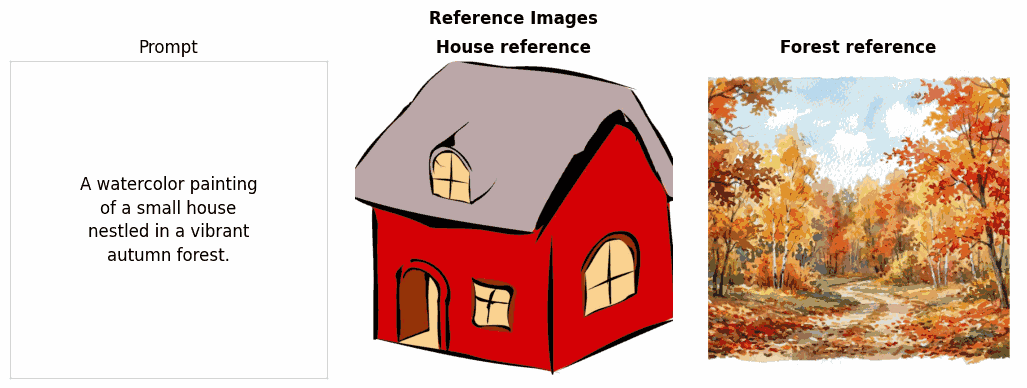

In [4]:
PROMPT = "A watercolor painting of a small house nestled in a vibrant autumn forest."

reference_image_path  = "img/ref_house.png"   # house reference
reference_image_path2 = "img/ref_forest.png"       # forest reference

ref_img  = Image.open(reference_image_path)
ref_img2 = Image.open(reference_image_path2)

show_images(
    [ref_img, ref_img2],
    titles=["House reference", "Forest reference"],
    main_title="Reference Images",
    prompt=PROMPT,
)

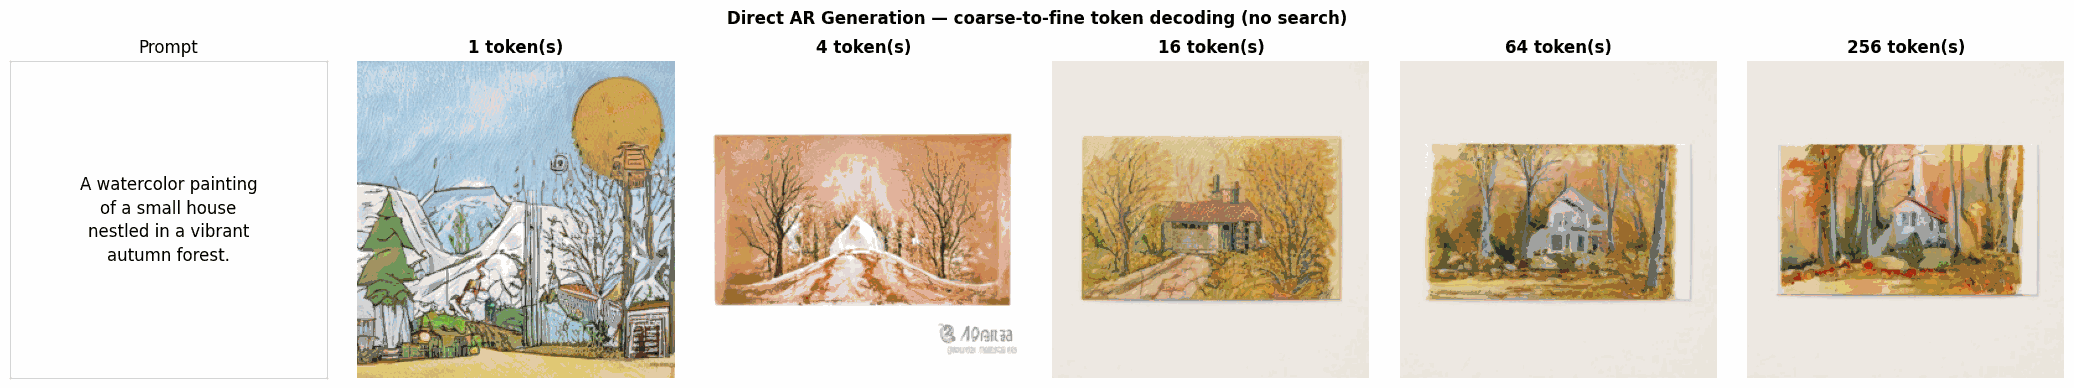

In [5]:
# Baseline: generate directly from text (no search).
# We decode partial prefixes to visualise the coarse-to-fine generation process.
FLEX_TOKEN_COUNTS = [1, 4, 16, 64, 256]

model   = ar_prior.generator
gen_cfg = ar_prior.cfg.generation

with torch.no_grad(), torch.cuda.amp.autocast(enabled=True, dtype=torch.float32):
    direct_tokens = model.generate_ids(
        {"text": [PROMPT]},
        cfg_factor=gen_cfg.get("cfg_factor", 3.0),
        num_keep_tokens=256,
        generator=torch.Generator(device=device).manual_seed(FIXED_SEED),
    )

flex_partial_images = []
for n_tok in FLEX_TOKEN_COUNTS:
    imgs = ar_prior.decode_tokens(direct_tokens[:, :n_tok], timesteps=15, caption_idx=0)
    flex_partial_images.append(imgs[0])

show_images(
    flex_partial_images,
    titles=[f"{n_tok} token(s)" for n_tok in FLEX_TOKEN_COUNTS],
    main_title="Direct AR Generation — coarse-to-fine token decoding (no search)",
    prompt=PROMPT,
)

Step 16/16: 100%|██████████| 16/16 [04:28<00:00, 16.75s/step, score=0.518, tokens=32]


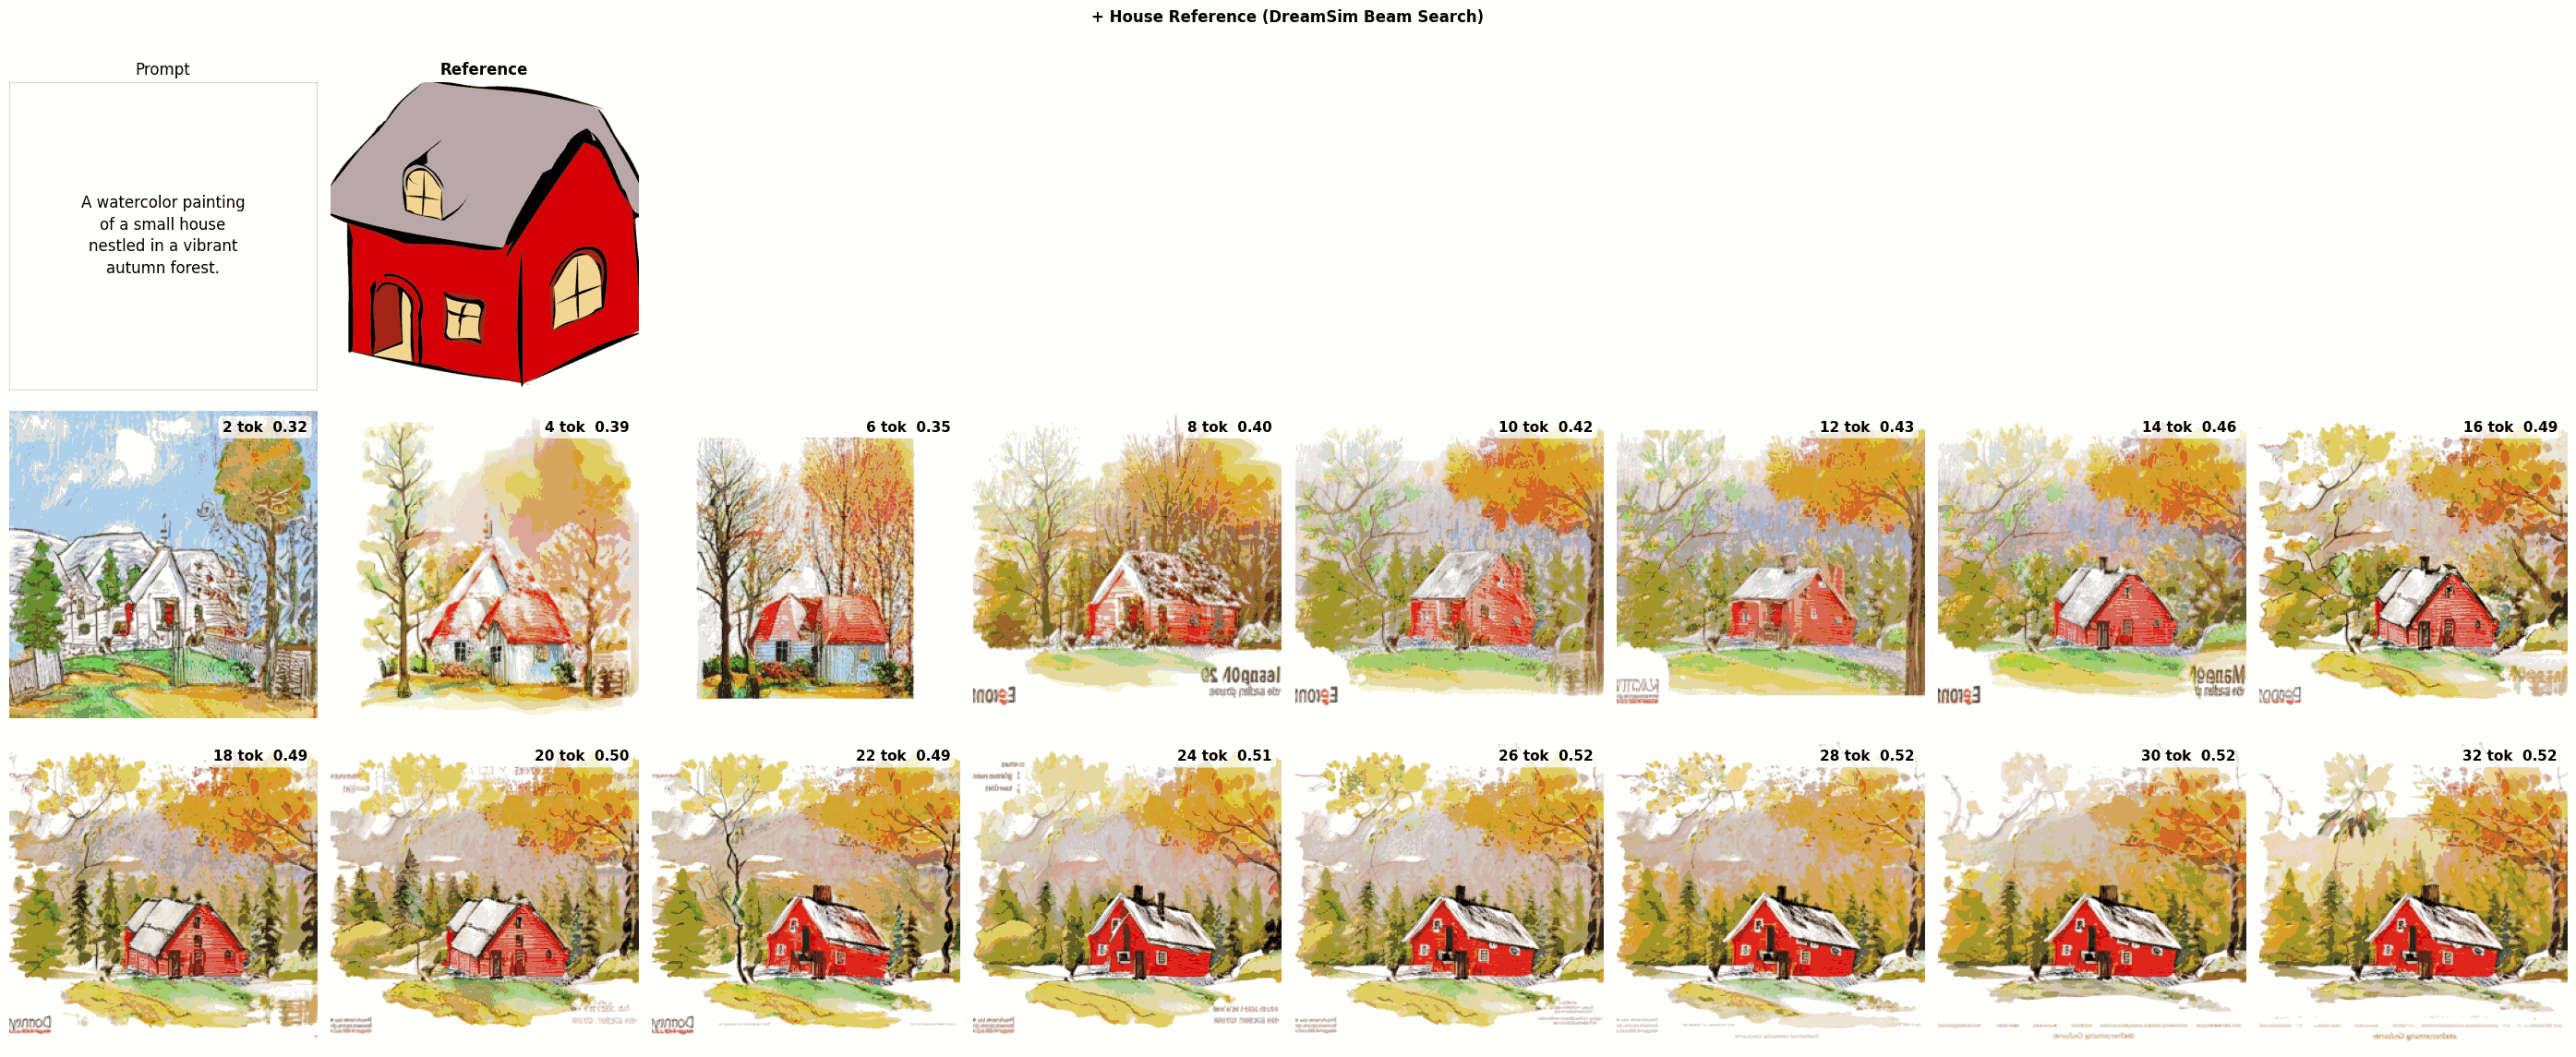

In [6]:
# DreamSim-guided beam search: explores token sequences and keeps those
# whose decoded images are most perceptually similar to the reference.
# We search over early tokens (1–32) where global structure is determined.

# Takes around 4min to finish on a h100.
dreamsim_searcher = SearchAlgorithmFactory.create(
    "beam", ar_prior, dreamsim_verifier,
    config={
        "beam_width": 5,
        "candidates_per_beam": 10,
        "token_schedule": "linear",
        "tokens_per_step": 2,
        "max_steps": 16,
        "decode_timesteps": 15,
        "sample": True,
    }
)

dreamsim_result = dreamsim_searcher.search(PROMPT, metadata=reference_image_path, seed=FIXED_SEED)

show_images(
    [ref_img] + dreamsim_result.step_images,
    titles=["Reference"] + [None] * len(dreamsim_result.step_images),
    overlay_labels=[None] + [
        f"{t} tok  {s:.2f}" for t, s in zip(
            dreamsim_result.metadata.get("step_schedule", []), dreamsim_result.step_scores)
    ],
    main_title="+ House Reference (DreamSim Beam Search)",
    prompt=PROMPT,
    first_row_cols=1,
    ncols=8,
)

Step 16/16: 100%|██████████| 16/16 [04:25<00:00, 16.60s/step, score=0.808, tokens=32]


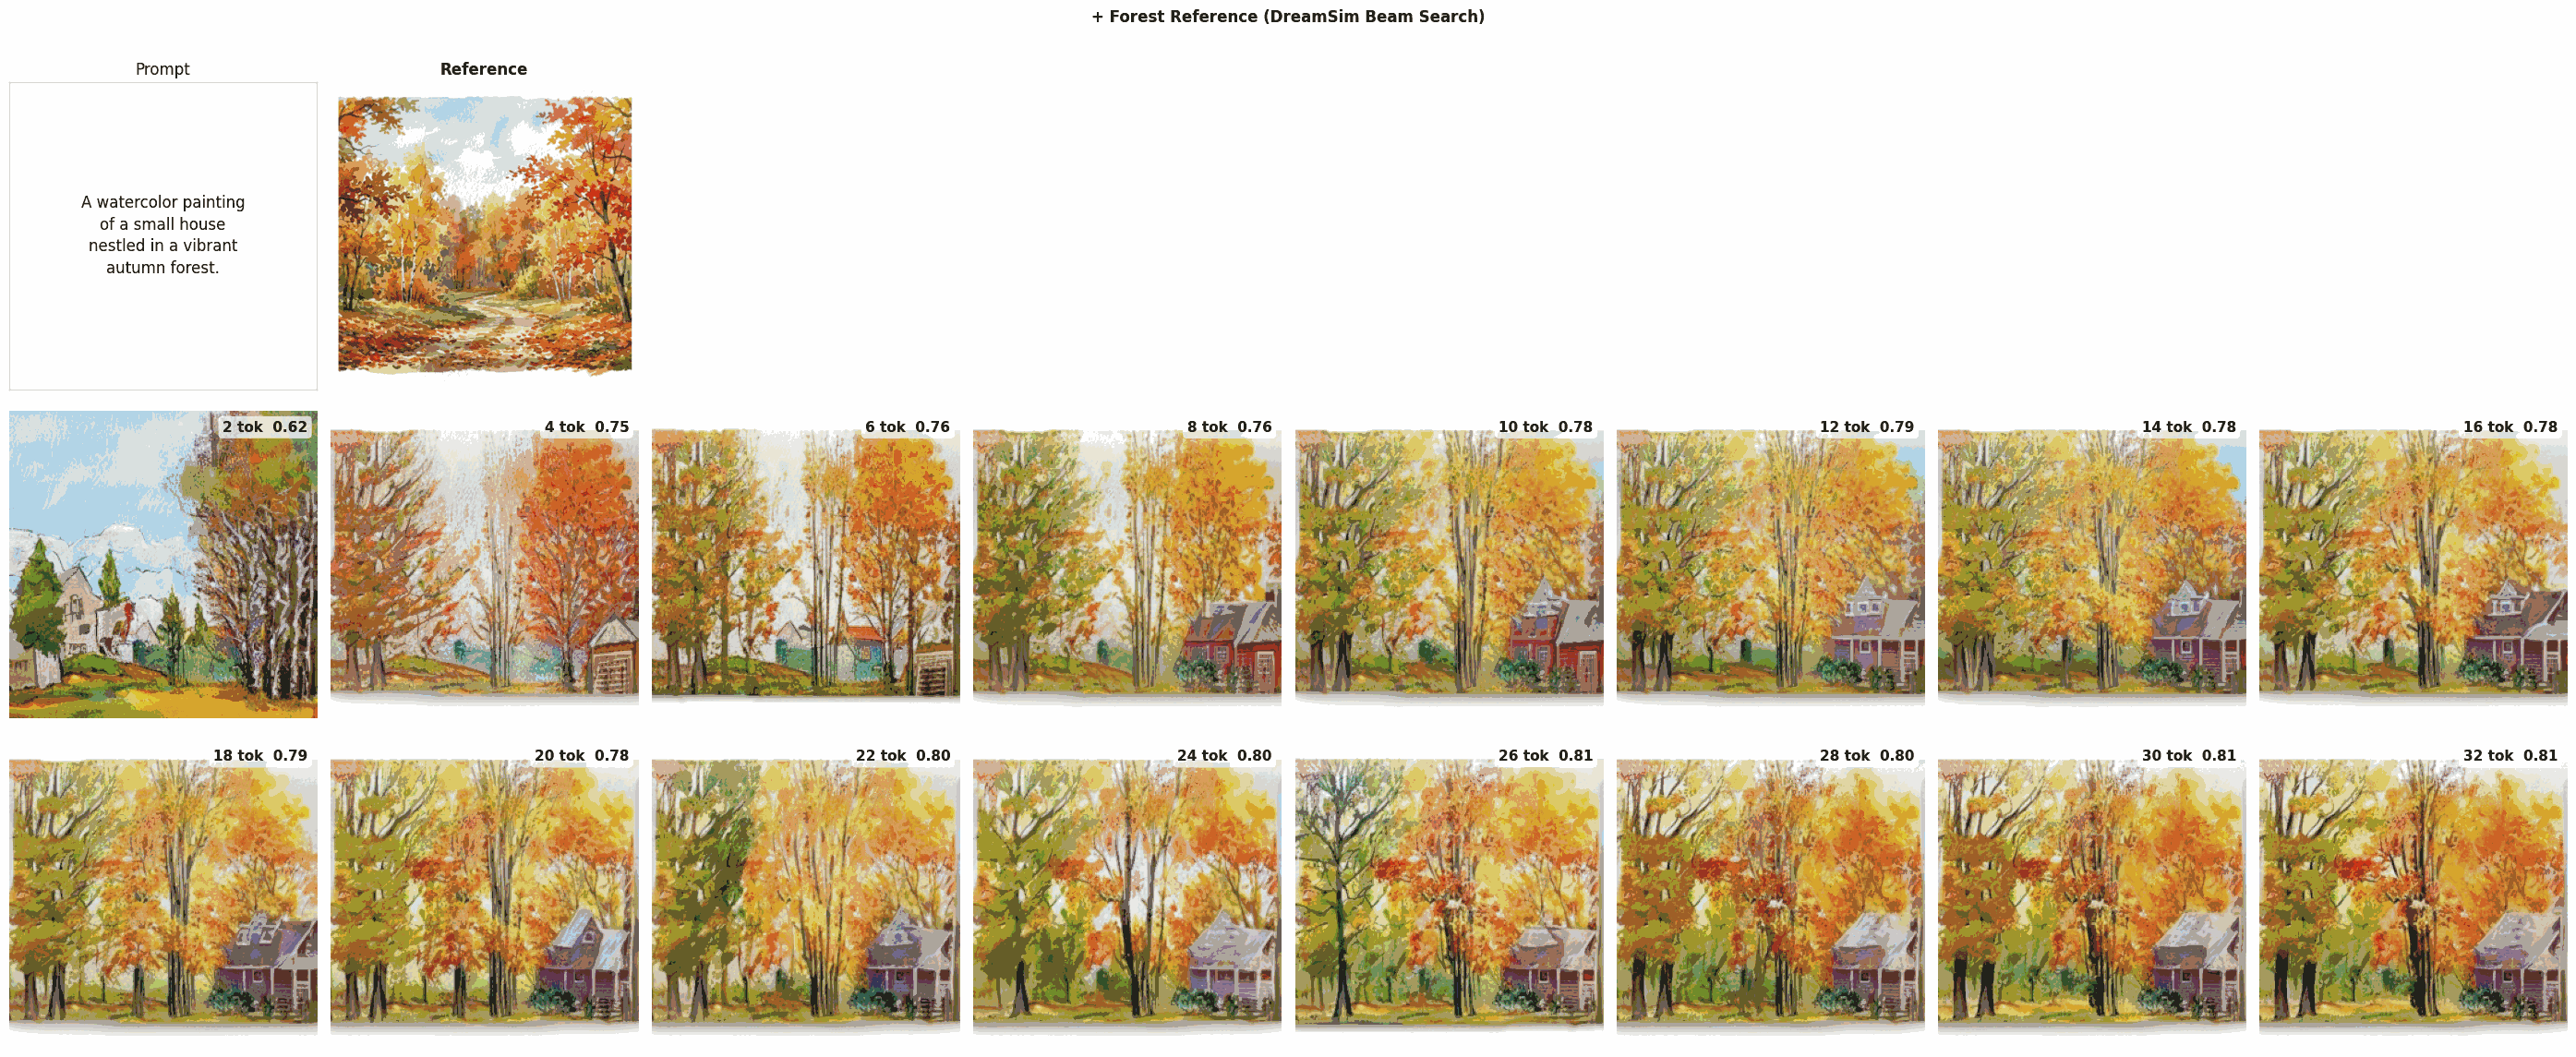

In [7]:
# Same searcher, different reference — steers generation toward a forest scene.
dreamsim_result2 = dreamsim_searcher.search(PROMPT, metadata=reference_image_path2, seed=FIXED_SEED)

show_images(
    [ref_img2] + dreamsim_result2.step_images,
    titles=["Reference"] + [None] * len(dreamsim_result2.step_images),
    overlay_labels=[None] + [
        f"{t} tok  {s:.2f}" for t, s in zip(
            dreamsim_result2.metadata.get("step_schedule", []), dreamsim_result2.step_scores)
    ],
    main_title="+ Forest Reference (DreamSim Beam Search)",
    prompt=PROMPT,
    first_row_cols=1,
    ncols=8,
)

---
## 2. Text-to-Image Verifiers

Text-to-image verifiers score how well a generated image matches a **text prompt**.
Running beam search with different verifiers on the same prompt reveals what each one captures and how they differ in practice.

| Verifier | What it measures |
|---|---|
| `image_reward` | Human-rated T2I quality |
| `clip` | Text–image semantic alignment |
| `aesthetic` | Visual appeal, style-agnostic |
| `hpsv2` | Human preference for realistic images |
| `pickscore` | Human preference across diverse styles |
| `cyclereward` | Round-trip (image→text→image) faithfulness |
| `likelihood` | AR model's own log-probability (no image decode needed) |
| `grounded_sam` | Compositional: object presence, color, and spatial position |

Optional dependency note for `grounded_sam`:

```bash
# Spatial verifier stack (GroundingDINO + SAM related deps; slower/heavier install)
pip install -e '.[spatial]'
```


In [8]:
# Load all verifiers — each will be used in a separate beam search run below.
verifiers = {
    "ImageReward": VerifierFactory.create("image_reward", device=device),
    "CLIP":        VerifierFactory.create("clip", {"name": "clip", "model_name": "ViT-B/16"}, device=device),
    "Aesthetic":   VerifierFactory.create("aesthetic",    device=device),
    "HPSv2":       VerifierFactory.create("hpsv2",        device=device),
    "PickScore":   VerifierFactory.create("pickscore",    device=device),
    "CycleReward": VerifierFactory.create("cyclereward",  device=device),
    "Likelihood":  VerifierFactory.create("likelihood",   {"requires_images": True}, device=device), #By default, the likelihood verifier does not require images and is therefore very fast. Here, we set requires_images = True to compare the intermediate selected images with those from other verifiers.
    "Grounded SAM":VerifierFactory.create("grounded_sam", device=device),
}


In [9]:
print(f"Prompt: {PROMPT}")

# Grounded SAM metadata: specifies which objects must appear, their optional color,
# and their position relative to an anchor object (referenced by index).
# Objects not assigned a position are unconstrained.
spatial_metadata = {
    "include": [
        {"class": "house",   "count": 1, "color": "red"},                             # index 0 — anchor; "color: red" added to demonstrate color constraint
        {"class": "tree",    "count": 1, "position": ("to the left of",  0)},         # index 1 — tree left of house
        {"class": "tree",    "count": 1, "position": ("to the right of", 0)},         # index 2 — tree right of house
    ]
}

# Shared beam search config for all verifier experiments.
# Increase beam_width / candidates_per_beam for higher quality (at the cost of time).
BEAM_CFG = {
    "beam_width": 3,
    "candidates_per_beam": 5,
    "token_schedule": [1, 4, 8, 16, 32],
    "decode_batch_size": 15,
    "decode_timesteps": 15,
}


Prompt: A watercolor painting of a small house nestled in a vibrant autumn forest.


In [10]:
# Run beam search with each verifier. (~4 min on H100)
# Grounded SAM uses spatial_metadata to check objects; all other verifiers ignore it.
results_by_verifier = {}

for name, verifier in verifiers.items():
    torch.cuda.empty_cache()
    print(f"  {name}...")
    searcher = SearchAlgorithmFactory.create("beam", ar_prior, verifier, BEAM_CFG)
    results_by_verifier[name] = searcher.search(PROMPT, metadata=spatial_metadata, seed=FIXED_SEED)


  ImageReward...


Step 5/5: 100%|██████████| 5/5 [00:28<00:00,  5.78s/step, score=1.196, tokens=32]


  CLIP...


Step 5/5: 100%|██████████| 5/5 [00:24<00:00,  4.98s/step, score=0.944, tokens=32]


  Aesthetic...


...

Step 5/5: 100%|██████████| 5/5 [00:25<00:00,  5.02s/step, score=2.490, tokens=32]


  Likelihood...


Step 5/5: 100%|██████████| 5/5 [00:24<00:00,  4.92s/step, score=-2.760, tokens=32]


  Grounded SAM...


Step 5/5: 100%|██████████| 5/5 [01:03<00:00, 12.68s/step, score=0.569, tokens=32]


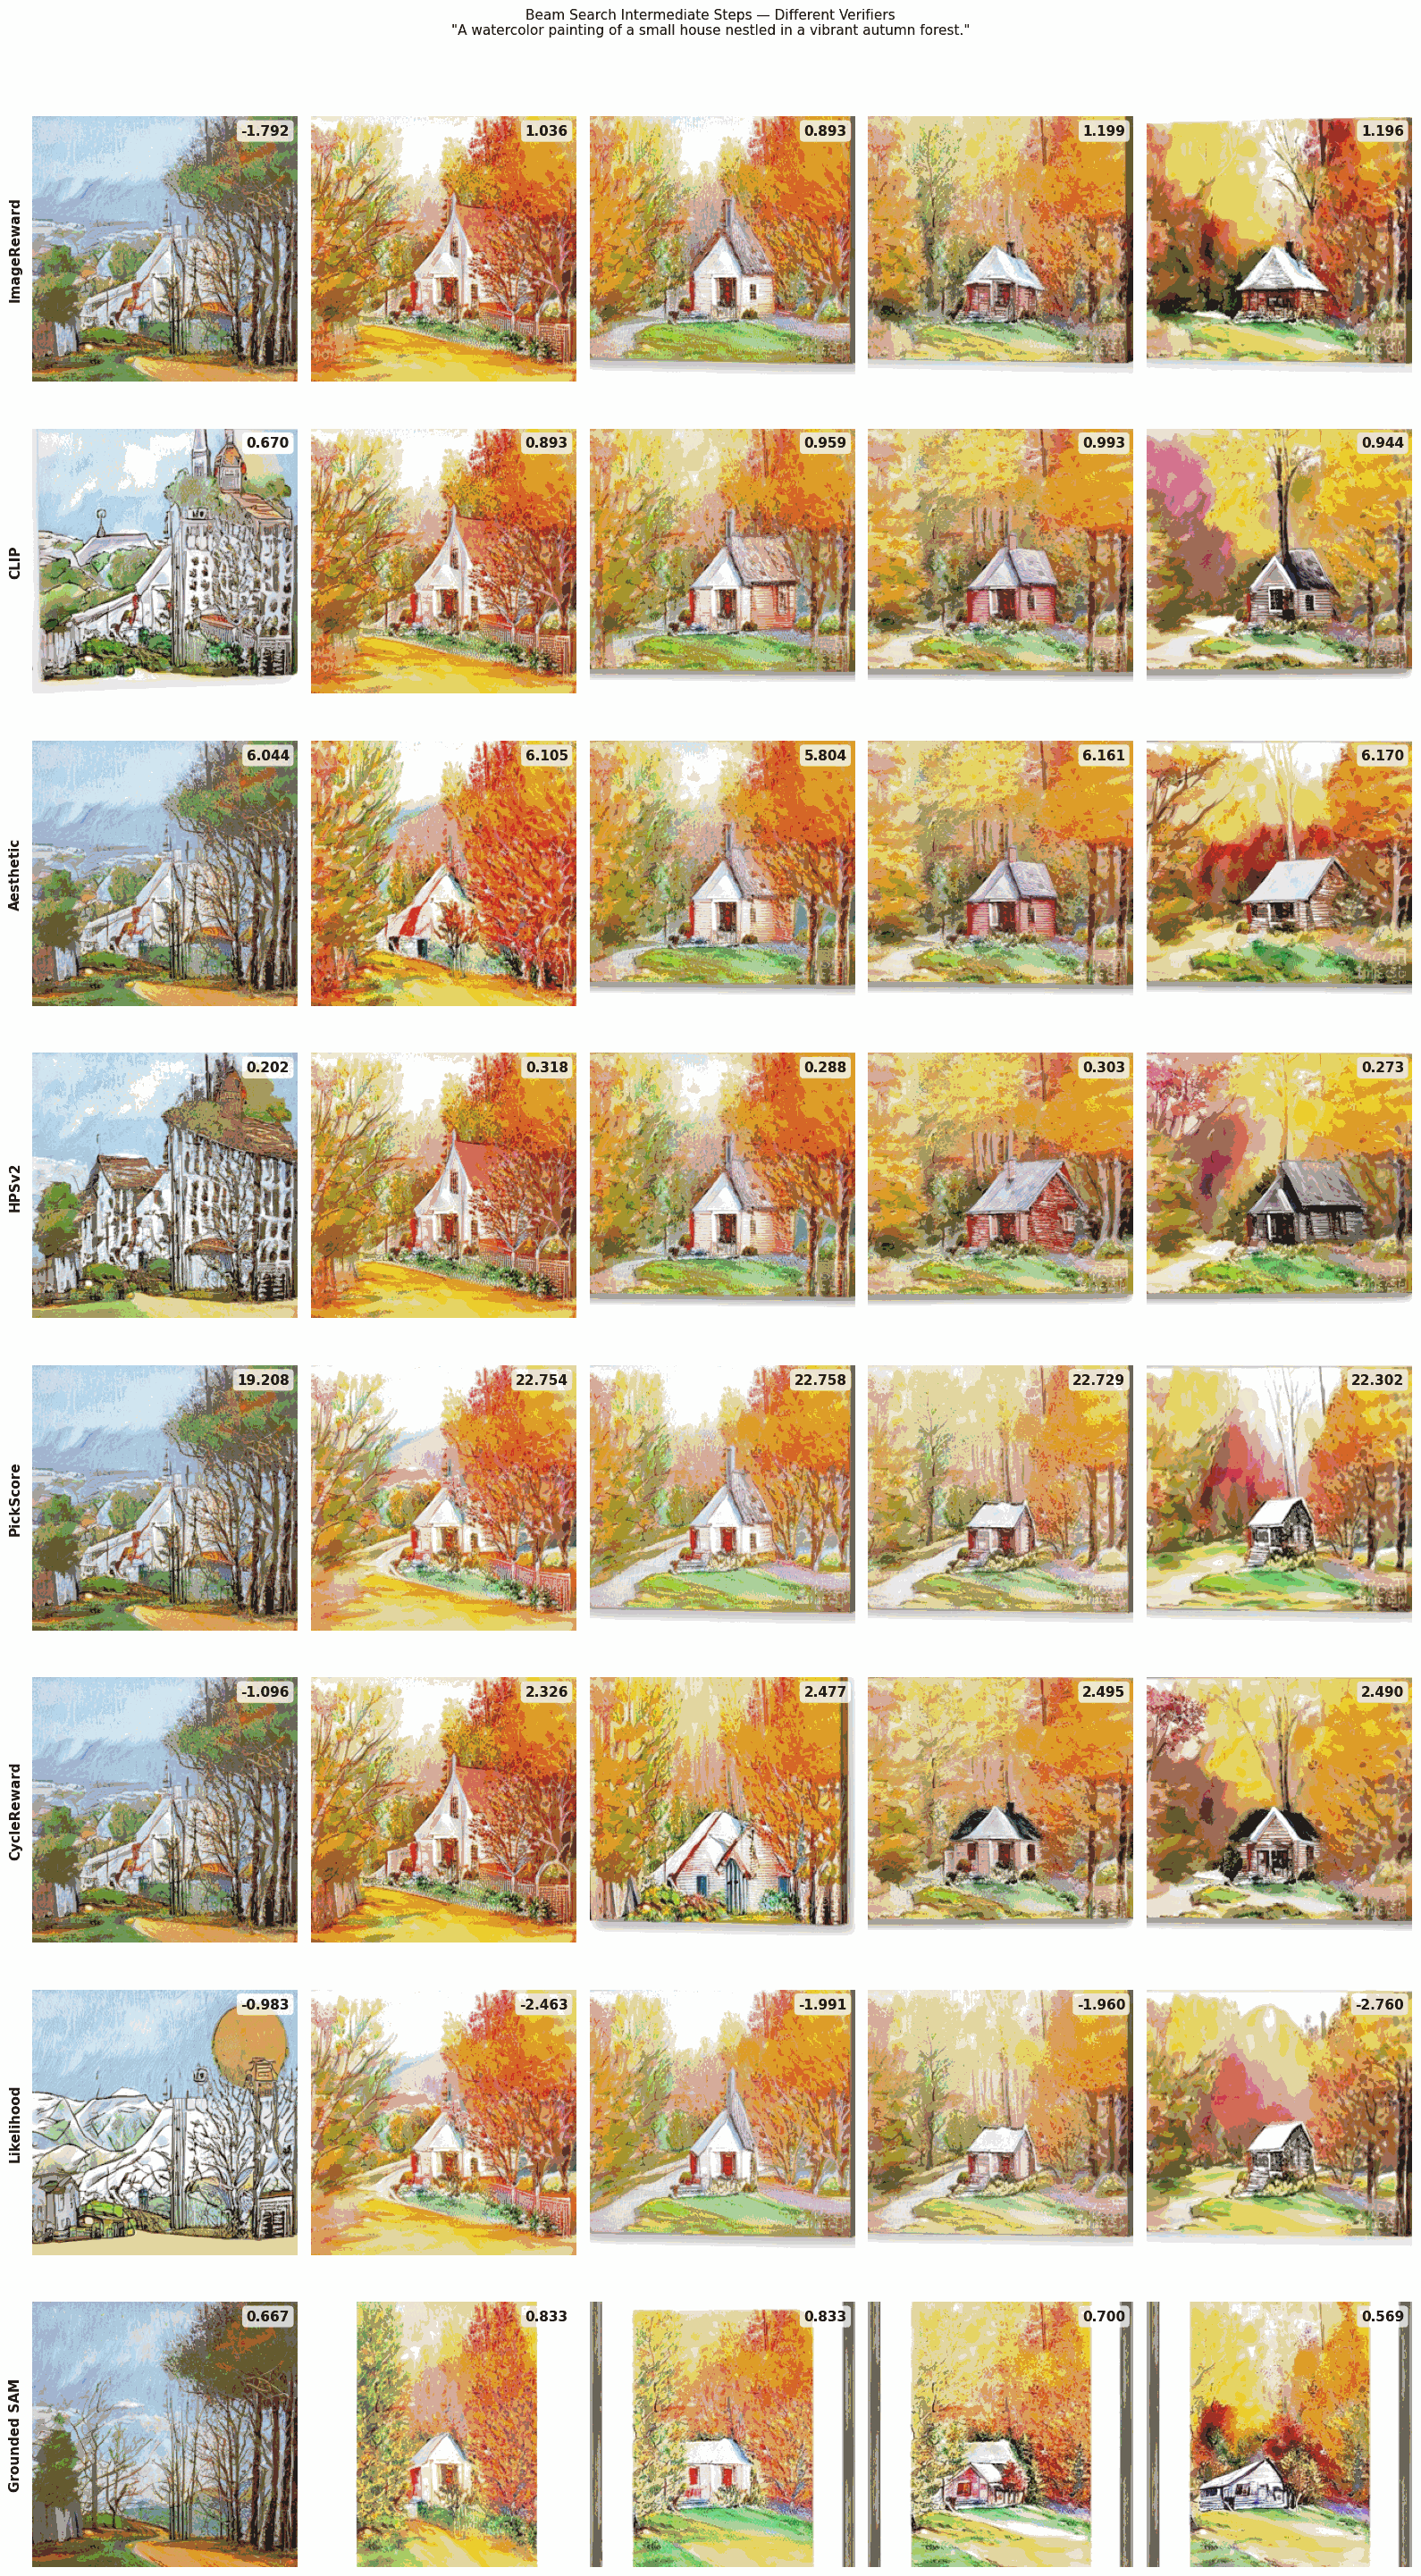

In [11]:
# Each row shows one verifier's beam search progression; overlay = verifier score at each step.
show_rows(
    [
        (name, result.step_images, [f"{s:.3f}" for s in result.step_scores])
        for name, result in results_by_verifier.items()
    ],
    title=f'Beam Search Intermediate Steps — Different Verifiers\n"{PROMPT}"',
)


---
## 3. Ensemble Verifier

The **Ensemble Verifier** combines multiple verifiers into a single score, balancing their strengths and reducing the failure modes of any single metric.

Two aggregation strategies:
- **Rank-based** (default): each verifier independently ranks candidates; the final score is the sum of ranks. Robust to scale differences between verifiers.
- **Weighted**: weighted sum of min-max normalised scores — useful when emphasising specific verifiers.

In [12]:
ensemble_verifier = VerifierFactory.create(
    "ensemble",
    {
        "name": "ensemble",
        "aggregation": "rank",   # "rank" (default, scale-robust) or "weighted"
        "verifiers": [
            {"name": "image_reward", "weight": 1.0},
            {"name": "clip",         "weight": 1.0, "model_name": "ViT-B/16"},
            {"name": "aesthetic",    "weight": 1.0},
            {"name": "hpsv2",        "weight": 1.0},
            {"name": "pickscore",    "weight": 1.0},
            {"name": "cyclereward",  "weight": 1.0},
            {"name": "likelihood",   "weight": 1.0},
            {"name": "grounded_sam", "weight": 1.0},
        ],
    },
    device=device,
)


In [13]:
ens_searcher = SearchAlgorithmFactory.create("beam", ar_prior, ensemble_verifier, BEAM_CFG)
ens_result = ens_searcher.search(PROMPT, num_results=5, metadata=spatial_metadata, seed=FIXED_SEED)
print(f"Top-5 ensemble scores: {[f'{s:.2f}' for s in ens_result.scores.tolist()]}")


Step 5/5: 100%|██████████| 5/5 [01:08<00:00, 13.67s/step, score=0.643, tokens=32]


Top-5 ensemble scores: ['0.64', '0.62', '0.60', '0.57', '0.55']


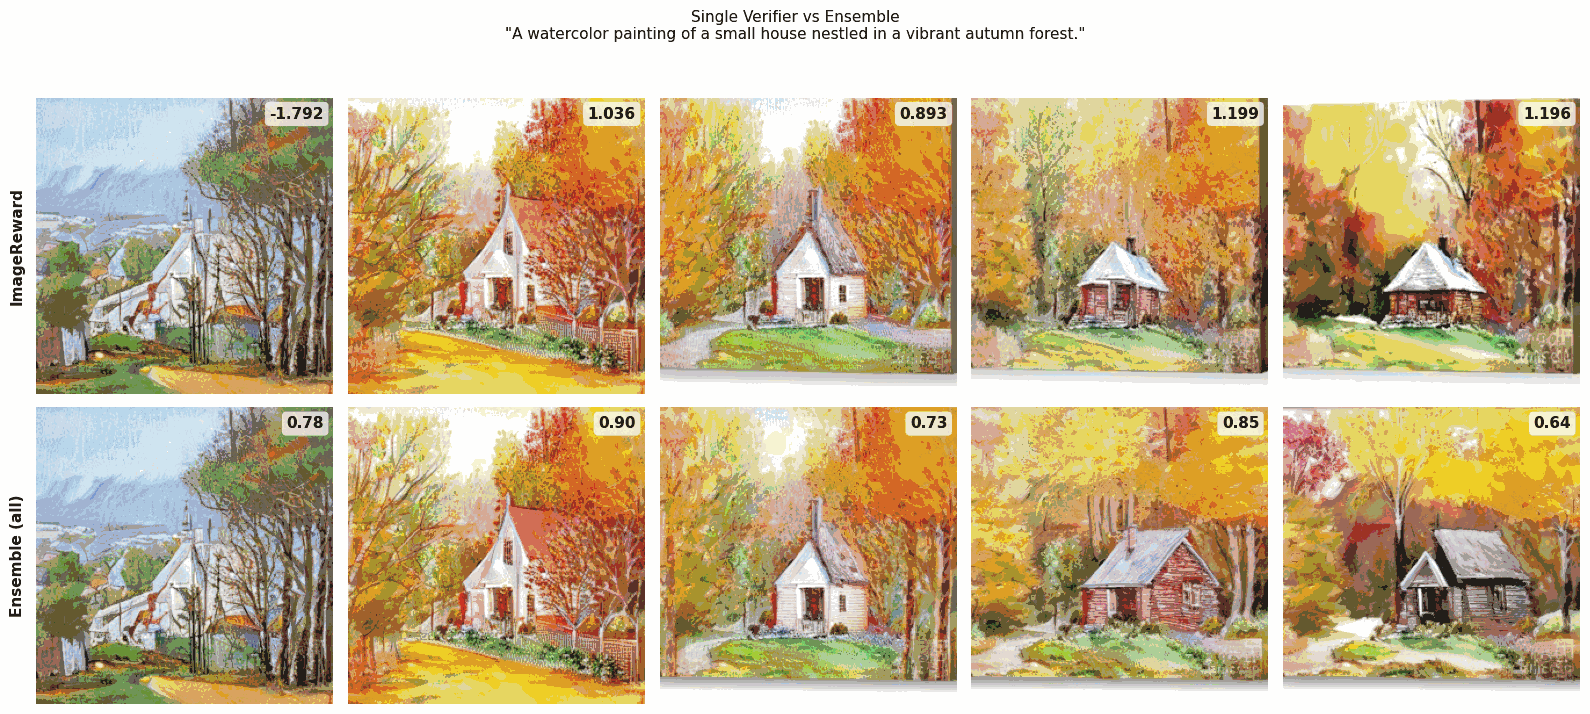

In [14]:
# Compare a single verifier (ImageReward) against the full ensemble.
show_rows(
    [
        ("ImageReward",
         results_by_verifier["ImageReward"].step_images[:5],
         [f"{s:.3f}" for s in results_by_verifier["ImageReward"].step_scores[:5]]),
        ("Ensemble (all)",
         ens_result.step_images[:5],
         [f"{s:.2f}" for s in ens_result.step_scores[:5]]),
    ],
    title=f'Single Verifier vs Ensemble\n"{PROMPT}"',
)

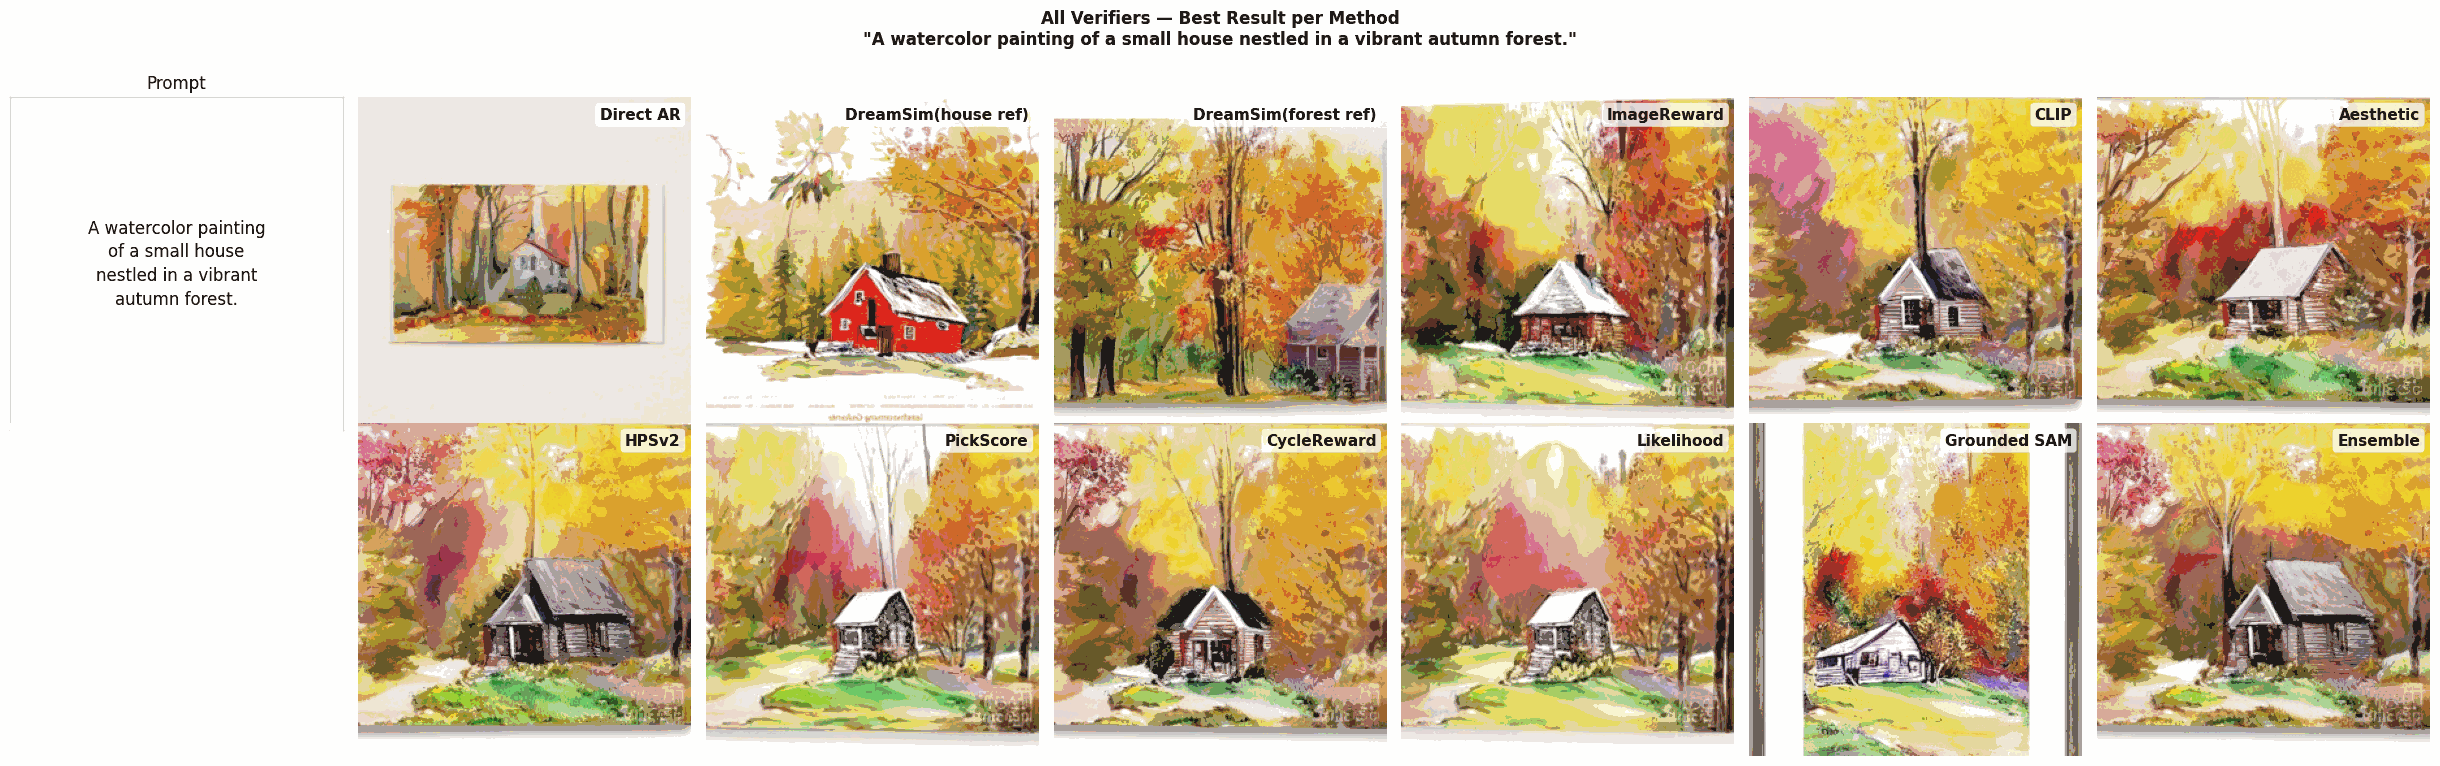

In [15]:
# Final summary: best result from each verifier on the same prompt.
# Row 0: Direct AR | DreamSim×2 | ImageReward | CLIP | Aesthetic | (blank)
# Row 1: HPSv2 | PickScore | CycleReward | Likelihood | Grounded SAM | Ensemble
_blank = Image.new("RGB", (256, 256), "white")

show_images(
    [
        flex_partial_images[-1],
        dreamsim_result.images[0], dreamsim_result2.images[0],
        results_by_verifier["ImageReward"].images[0],
        results_by_verifier["CLIP"].images[0],
        results_by_verifier["Aesthetic"].images[0],
        _blank,                                             # blank to align row break
        results_by_verifier["HPSv2"].images[0],
        results_by_verifier["PickScore"].images[0],
        results_by_verifier["CycleReward"].images[0],
        results_by_verifier["Likelihood"].images[0],
        results_by_verifier["Grounded SAM"].images[0],
        ens_result.images[0],
    ],
    overlay_labels=[
        "Direct AR",
        "DreamSim(house ref)",
        "DreamSim(forest ref)",
        "ImageReward", "CLIP", "Aesthetic",
        None,                                               # blank cell — no label
        "HPSv2", "PickScore", "CycleReward",
        "Likelihood", "Grounded SAM", "Ensemble",
    ],
    main_title=f'All Verifiers — Best Result per Method\n"{PROMPT}"',
    ncols=7,
    prompt=PROMPT,
)

## Takeaways
- Verifiers define the objective during test-time search, enabling more flexible control over generation at inference time.
- We show that verifiers can be used to add image-level control during generation through image–image similarity, or to enhance prompt following via image–text similarity. A diverse set of models can serve as verifiers, including human reward models, large-scale image–text pretrained models, cycle-trained models, segmentation and detection models, or ensembles that combine multiple approaches for more robust evaluation.
- Developing better verifiers is critical for advancing test-time search in future research.